# 0. Stock Direction Classifier

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import sklearn

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Data Collection

## 1.1 Download data

In [4]:
ticker = "AAPL"

df = yf.download(ticker, start="2010-01-01", end="2024-01-01")

df = df[["Close"]] # Only keep the 'Close' column
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2010-01-04,6.406479
2010-01-05,6.417558
2010-01-06,6.315478
2010-01-07,6.303800
2010-01-08,6.345711


## 1.2 Plot closing prices

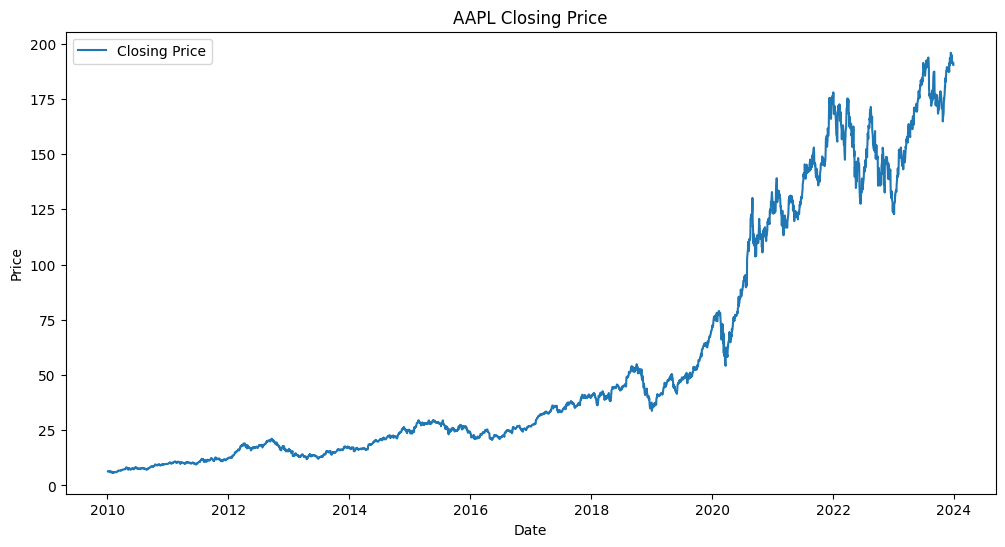

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"], label="Closing Price")
plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# 2. Feature Engineering

## 2.1 Log returns

In [ ]:
df["log_return"] = np.log(df["Close"]) / df["Close"].shift(1) # Calculate log returns

## 2.2 Technical features

In [ ]:
# Mobile averages
df["ma_5"] = df["Close"].rolling(5).mean()
df["ma_20"] = df["Close"].rolling(20).mean()

# Volatility
df["volatility_5"] = df["log_return"].rolling(5).std()
df["volatility_20"] = df["log_return"].rolling(20).std()

# Momentum
df["momentum_5"] = df["log_return"].rolling(5).sum()
df["momentum_20"] = df["log_return"].rolling(20).sum()

# Relative Strength Index (RSI)
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["rsi"] = compute_rsi(df["Close"])